# Mapping each sample on the atlas

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(dplyr)
    library(data.table)
    library(ggplot2)
    library(SingleCellExperiment)
    library(scater)
    library(scran)
    library(edgeR)
    library(ggrastr)
    library(batchelor)
    library(Seurat)
})

here::i_am("mapping/run/01_mapping_manual.ipynb")

# Load mapping functions
source(here::here("mapping/run/mnn/mapping_functions_extended.R"))

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/14_Yang/code



In [2]:
args = list()
args$atlas_sce = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/processed/SingleCellExperiment.rds'
args$atlas_metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata_extended.txt.gz'
args$atlas_stages = c('E7.5', 'E7.75', 'E8.0', 'E8.25', 'E8.5')
args$npcs = 40
args$n_neighbours = 15
args$cosine_normalisation = FALSE

args$seurat_yang = '/rds/project/rds-SDzz0CATGms/users/ltgh2/projects/17_Yang_Histone_Atlas/seurat_object_yang/scRNA.data.seurat.all.202411.processed2.rds'
args$outdir = paste0(io$basedir,"/results/rna/mapping/manual/")
dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)

In [30]:
################
## Load query ##
################

seurat = readRDS(args$seurat_yang)

In [31]:
count.mtx = seurat@assays$RNA@layers$counts
colnames(count.mtx) = rownames(seurat@assays$RNA@cells)
rownames(count.mtx) = rownames(seurat@assays$RNA@features)

sce_query = SingleCellExperiment(list(counts = count.mtx))
colData(sce_query) <- seurat@meta.data %>% DataFrame

In [33]:
metadata = as.data.table(colData(sce_query), keep.rownames = T) %>% setnames('rn', 'cell')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [48]:
sce_query = sce_query[, metadata[nCount_RNA > 2000 & nCount_RNA < 20000 & nFeature_RNA > 100, cell]]

In [49]:
metadata = metadata[match(colnames(sce_query), cell)]

In [50]:
sce_query$sample = paste0(metadata$orig.ident, '_', 
          #  metadata$sample_bio.id, '_', 
            metadata$sublib, '_', 
            metadata$batches
           )

In [51]:
meta_query = metadata
meta_query$sample = sce_query$sample

In [38]:
################
## Load atlas ##
################

# Load cell metadata
meta_atlas <- fread(args$atlas_metadata) %>%
  .[stage%in%args$atlas_stages] %>%
  .[,sample:=factor(sample)] 

# Filter
if (isTRUE(args$test)) meta_atlas <- head(meta_atlas,n=1000)

# Load SingleCellExperiment
sce_atlas <- load_SingleCellExperiment(args$atlas_sce, normalise = TRUE, cells = meta_atlas$cell, remove_non_expressed_genes = TRUE)

# Update colData
tmp <- meta_atlas %>% .[cell%in%colnames(sce_atlas)] %>% setkey(cell) %>% .[colnames(sce_atlas)]
stopifnot(tmp$cell == colnames(sce_atlas))
colData(sce_atlas) <- tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce_atlas),] %>% DataFrame()

# Sanity cehcks
stopifnot(sum(is.na(rownames(sce_atlas)))==0)
stopifnot(sum(duplicated(rownames(sce_atlas)))==0)

In [39]:
#####################
## Define gene set ##
#####################

# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol", "description")] %>%
  .[symbol!="" & ens_id%in%rownames(sce_atlas)] %>%
  .[!duplicated(symbol)]

rownames(sce_atlas) = gene_metadata[match(rownames(sce_atlas), ens_id), symbol]

In [40]:
# Imprinted genes
imprint = gene_metadata[c(grep('maternally', gene_metadata$description),
                       grep('paternally', gene_metadata$description)), symbol]
#Other imprinted genes: 
#- Nnat (https://www.genecards.org/cgi-bin/carddisp.pl?gene=NNAT)
#- Grb10 (https://www.genecards.org/cgi-bin/carddisp.pl?gene=GRB10)

# Intersect genes
genes.intersect <- intersect(rownames(sce_query), rownames(sce_atlas))

# Filter some genes manually
# genes.intersect <- genes.intersect[grep("^Rik|Rik$|^mt-|^Rps|^Rpl|^Gm",genes.intersect,invert=T)] # filter out non-informative genes
genes.intersect <- genes.intersect[grep("^Hbb|^Hba",genes.intersect,invert=T)] # removing Haem genes 
# genes.intersect <- genes.intersect[!genes.intersect %in% c(imprint, 'Grb10', 'Nnat')] # remove imprinted genes
genes.intersect <- genes.intersect[!genes.intersect %in% c("Xist", "Tsix")] # remove Xist & Tsix
# genes.intersect <- genes.intersect[!genes.intersect=="tomato-td"] # remove tomato itself
genes.intersect <- genes.intersect[!genes.intersect %in% gene_metadata[chr=="chrY",symbol]] # no genes on y-chr 

# Subset SingleCellExperiment objects
sce_query  <- sce_query[genes.intersect,]
sce_atlas <- sce_atlas[genes.intersect,]

In [41]:
#######################
## Feature selection ##
#######################

# Load gene statistics from the atlas
gene_stats.dt <- fread(paste0(io$atlas.basedir,"/results/gene_statistics/gene_statistics.txt.gz")) %>%
.[gene%in%genes.intersect]
genes_to_use <- gene_stats.dt %>% setorder(-var_pseudobulk, na.last = T) %>% head(n=4000) %>% .$gene  

In [42]:
stopifnot(genes_to_use%in%rownames(sce_atlas))
stopifnot(genes_to_use%in%rownames(sce_query))

sce_query = sce_query[genes_to_use,]
sce_atlas = sce_atlas[genes_to_use,]

In [43]:
sce_query
sce_atlas

class: SingleCellExperiment 
dim: 4000 260535 
metadata(0):
assays(1): counts
rownames(4000): Tdgf1 Hoxaas3 ... Ypel5 Olig2
rowData names(0):
colnames(260535): E8.5:H3K27me3:01:01:10:S2:batch3
  E8.5:H3K27ac:01:01:27:S2:batch3 ... E7.5:mtr_seq:48:47:28:S1:batchEED
  E6.5:mtr_seq:48:47:31:S1:batchEED
colData names(26): orig.ident nCount_RNA ... RNA_snn_res.5 sample
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

class: SingleCellExperiment 
dim: 4000 75012 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(4000): Tdgf1 Hoxaas3 ... Ypel5 Olig2
rowData names(0):
colnames(75012): cell_361 cell_362 ... cell_139330 cell_139331
colData names(13): barcode sample ... index celltype_extended
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [44]:
sce_query = logNormCounts(sce_query)

In [53]:
table(sce_query$sample)


48835_SP1.S1_batch4 48835_SP1.S2_batch4 48835_SP1.S3_batch4 48835_SP1.S4_batch4 
               1951                2138                1668                3299 
48835_SP2.S1_batch4 48835_SP2.S2_batch4 48835_SP2.S3_batch4 48835_SP2.S4_batch4 
               3790                4832                4937                4197 
 lane8738_S1_batch6        S1_S1_batch3        S1_S1_batch5      S1_S1_batchEED 
                255                8151                5017                1426 
       S2_S2_batch3        S2_S2_batch5      S2_S2_batchEED        S3_S3_batch3 
               7797                5706                1208                7003 
       S3_S3_batch5      S3_S3_batchEED        S4_S4_batch3        S4_S4_batch5 
               6164                1319                7974                5377 
     S4_S4_batchEED        S5_S5_batch3        S6_S6_batch3        S7_S7_batch3 
               1316                7882                8041                7924 
       S8_S8_batch3 
      

In [61]:
unique(meta_query$sample)

[1] "S2_S2_batch3"        "S1_S1_batch3"        "S6_S6_batch3"       
 [4] "S3_S3_batch3"        "S5_S5_batch3"        "S4_S4_batch3"       
 [7] "S7_S7_batch3"        "S8_S8_batch3"        "48835_SP1.S1_batch4"
[10] "48835_SP1.S2_batch4" "48835_SP1.S3_batch4" "48835_SP1.S4_batch4"
[13] "48835_SP2.S1_batch4" "48835_SP2.S2_batch4" "48835_SP2.S3_batch4"
[16] "48835_SP2.S4_batch4" "S1_S1_batch5"        "S2_S2_batch5"       
[19] "S4_S4_batch5"        "S3_S3_batch5"        "lane8738_S1_batch6" 
[22] "S3_S3_batchEED"      "S4_S4_batchEED"      "S2_S2_batchEED"     
[25] "S1_S1_batchEED"

In [56]:
mapping_full = mclapply(unique(meta_query$sample), function(x){
    mapping  <- mapWrap(
          sce_atlas = sce_atlas,
          meta_atlas = meta_atlas,
          sce_query = sce_query[,meta_query[sample==x, cell]],
          meta_query = meta_query[sample==x, ],
          genes = genes_to_use,
          npcs = args$npcs,
          k = args$n_neighbours,
          cosineNorm = args$cosine_normalisation,
          order = NULL
        )
    
    mapping.dt <- mapping$mapping %>% 
      .[,c("cell","celltype.mapped","celltype.score","celltype_extended.mapped","celltype_extended.score","stage.mapped", "cellstage.score", "closest.cell")] %>% 
      as.data.table
    
    return(mapping.dt)
}, mc.cores=1)

In [64]:
mapping_full = mapping_full %>% rbindlist()

In [65]:
nrow(mapping_full)

[1] 117411

In [71]:
nrow(meta_query)

[1] 117411

In [70]:
table(mapping_full$celltype_extended.mapped_mnn)


                Allantois_endothelium                     Amniotic_ectoderm 
                                 1140                                     1 
Anterior_cardiopharyngeal_progenitors             Anterior_Primitive_Streak 
                                  154                                   564 
             Anterior_somitic_tissues                     Blood_progenitors 
                                  297                                  3489 
                 Cardiomyocytes_FHF_1                  Cardiomyocytes_FHF_2 
                                  548                                   268 
                 Cardiomyocytes_SHF_1                  Cardiomyocytes_SHF_2 
                                  282                                     7 
         Cardiopharyngeal_progenitors      Cardiopharyngeal_progenitors_FHF 
                                    8                                     6 
     Cardiopharyngeal_progenitors_SHF                       Caudal_epiblast

In [67]:
mapping_full = mapping_full %>% setnames(colnames(mapping_full)[-1], paste0(colnames(mapping_full)[-1], '_mnn'))

In [68]:
meta_full = merge(meta_query, mapping_full, by='cell') %>% 
    .[match(colnames(sce_query), cell)]

In [69]:
fwrite(meta_full, file.path(args$outdir, 'sample_metadata_after_mapping.txt.gz'), sep="\t")

In [72]:
hvgs = VariableFeatures(FindVariableFeatures(as.Seurat(sce_query), nfeatures = 4000))

In [74]:
sce_filt <- runPCA(sce_query[hvgs,], ncomponents = 50, ntop=4000)  


In [75]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 35, min_dist = 0.3)

In [76]:
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>%
    merge(., mapping_full, by = 'cell')

In [77]:
head(umap.dt)

cell,UMAP1,UMAP2,celltype.mapped_mnn,celltype.score_mnn,celltype_extended.mapped_mnn,celltype_extended.score_mnn,stage.mapped_mnn,cellstage.score_mnn,closest.cell_mnn
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>
E6.5:mtr_seq:01:02:17:S1:batchEED,-3.697010,-13.742540,ExE_ectoderm,1.0000000,ExE_ectoderm,1.0000000,E8.0,0.4000000,cell_46440
E6.5:mtr_seq:01:03:16:S1:batchEED,-3.448242,-12.374937,ExE_ectoderm,1.0000000,ExE_ectoderm,1.0000000,E8.25,0.4000000,cell_66690
E6.5:mtr_seq:01:03:17:S1:batchEED,-2.403200,-7.839569,Rostral_neurectoderm,0.5333333,Ectoderm,0.7333333,E7.75,0.6666667,cell_9361
E6.5:mtr_seq:01:04:18:S1:batchEED,-1.933866,-7.271551,Rostral_neurectoderm,0.6666667,Ectoderm,0.6000000,E7.5,0.6000000,cell_23178
E6.5:mtr_seq:01:04:18:S2:batchEED,-3.891554,-11.473773,ExE_ectoderm,1.0000000,ExE_ectoderm,1.0000000,E7.75,0.6000000,cell_8603
E6.5:mtr_seq:01:04:21:S3:batchEED,-3.653920,-14.060667,ExE_ectoderm,1.0000000,ExE_ectoderm,1.0000000,E7.75,0.4000000,cell_74620


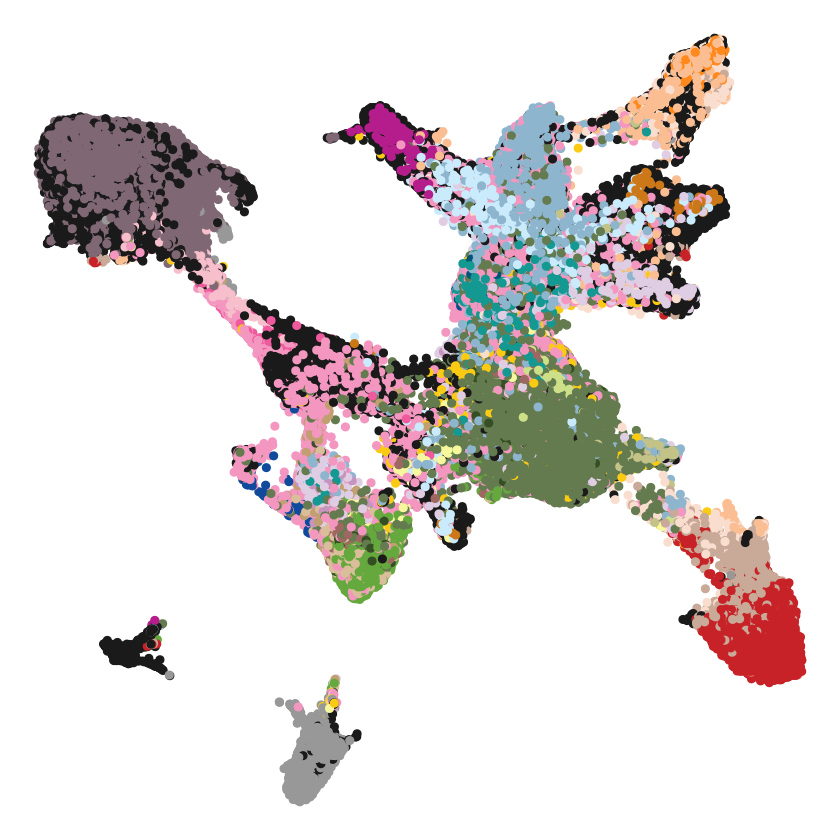

In [79]:
ggplot(umap.dt, aes(UMAP1, UMAP2, color = celltype.mapped_mnn)) +
    geom_point() + 
    scale_color_manual(values = opts$celltype.colors) +
    theme_void() + 
    theme(legend.position = 'none')

In [87]:
sce_query

class: SingleCellExperiment 
dim: 4000 117411 
metadata(0):
assays(2): counts logcounts
rownames(4000): Tdgf1 Hoxaas3 ... Ypel5 Olig2
rowData names(0):
colnames(117411): E8.5:H3K27me3:01:01:10:S2:batch3
  E8.5:H3K27ac:01:01:27:S2:batch3 ... E7.5:mtr_seq:48:47:28:S1:batchEED
  E6.5:mtr_seq:48:47:31:S1:batchEED
colData names(27): orig.ident nCount_RNA ... sample sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [94]:
count.mtx = seurat@assays$RNA@layers$counts
colnames(count.mtx) = rownames(seurat@assays$RNA@cells)
rownames(count.mtx) = rownames(seurat@assays$RNA@features)

sce_query = SingleCellExperiment(list(counts = count.mtx))
colData(sce_query) <- seurat@meta.data %>% DataFrame
sce_query = logNormCounts(sce_query)

In [124]:
plot_gene = function(gene){
    umap.dt$gene = as.vector(logcounts(sce_query[gene, umap.dt$cell]))
    umap.dt = umap.dt[order(gene)]
    ggplot(umap.dt, aes(UMAP1, UMAP2, color = gene)) +
        geom_point(size = 0.2) + 
        viridis::scale_color_viridis() + 
        theme_void() + 
        theme(legend.position = 'none')
}

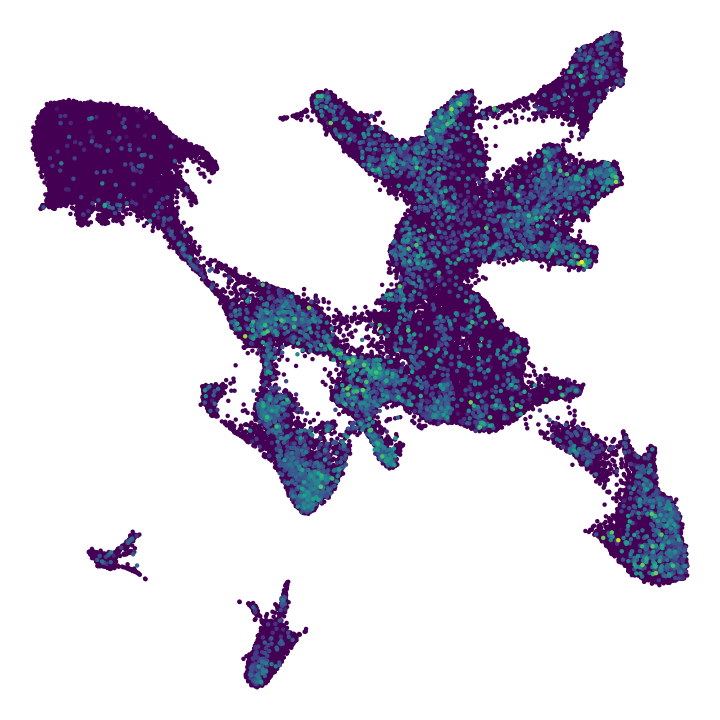

In [146]:
options(repr.plot.width=6, repr.plot.height=6)

plot_gene("Lancl3")

#### Integration over full dataset to get common embedding

In [80]:
# Full dimensionality reduction
mapping  <- mapWrap(
      sce_atlas = sce_atlas,
      meta_atlas = meta_atlas,
      sce_query = sce_query,
      meta_query = meta_query,
      genes = genes_to_use,
      npcs = args$npcs,
      k = args$n_neighbours,
      cosineNorm = args$cosine_normalisation,
      order = NULL
    )

mapping.dt <- mapping$mapping %>% 
  .[,c("cell","celltype.mapped","celltype.score","celltype_extended.mapped","celltype_extended.score","stage.mapped", "cellstage.score", "closest.cell")] %>% 
  as.data.table

Normalizing joint dataset using cosineNorm=FALSE...

Done


4000 Genes provided...

Performing PCA...

Done


Batch effect correction for the atlas...

Done


MNN mapping...

Done


Computing mapping scores...

Done


Writing output...

Done




In [81]:
PCA = rbind(mapping$pca_atlas_corrected, mapping$pca_query_corrected)

In [82]:
meta_big = rbind(meta_atlas[,c('cell', 'celltype', 'celltype_extended')] %>% .[,origin:='atlas'],
                 mapping.dt[,c('cell', 'celltype.mapped', 'celltype_extended.mapped')] %>% 
                setnames(c('cell', 'celltype', 'celltype_extended'))  %>% .[,origin:='chimera']) %>%
    .[match(rownames(PCA), cell)]

In [83]:
UMAP <- as.data.table(calculateUMAP(t(PCA), n_neighbors = 25, min_dist = 0.3)) %>%
    setnames(c('UMAP1', 'UMAP2')) %>% 
    .[,cell:=rownames(PCA)] %>% 
    merge(., meta_big, by='cell')

In [84]:
options(repr.plot.width=15, repr.plot.height=6)
p1 = ggplot(UMAP[sample(nrow(UMAP), nrow(UMAP))], aes(UMAP1, UMAP2, color=origin)) + 
    geom_point(size=0.05) + 
 #   scale_color_manual(values=c(opts$celltype.colors, opts$celltype_extended.colors)) + 
    theme_void() + 
    theme(legend.position='none',
          strip.background=element_blank(),
          strip.text=element_text(size=20))

options(repr.plot.width=15, repr.plot.height=6)
p2 = ggplot(UMAP, aes(UMAP1, UMAP2, color=celltype_extended)) + 
    geom_point(size=0.5) + 
    scale_color_manual(values=c(opts$celltype.colors, opts$celltype_extended.colors)) + 
    facet_wrap(~origin) + 
    theme_void() + 
    theme(legend.position='none',
          strip.background=element_blank(),
          strip.text=element_text(size=20))

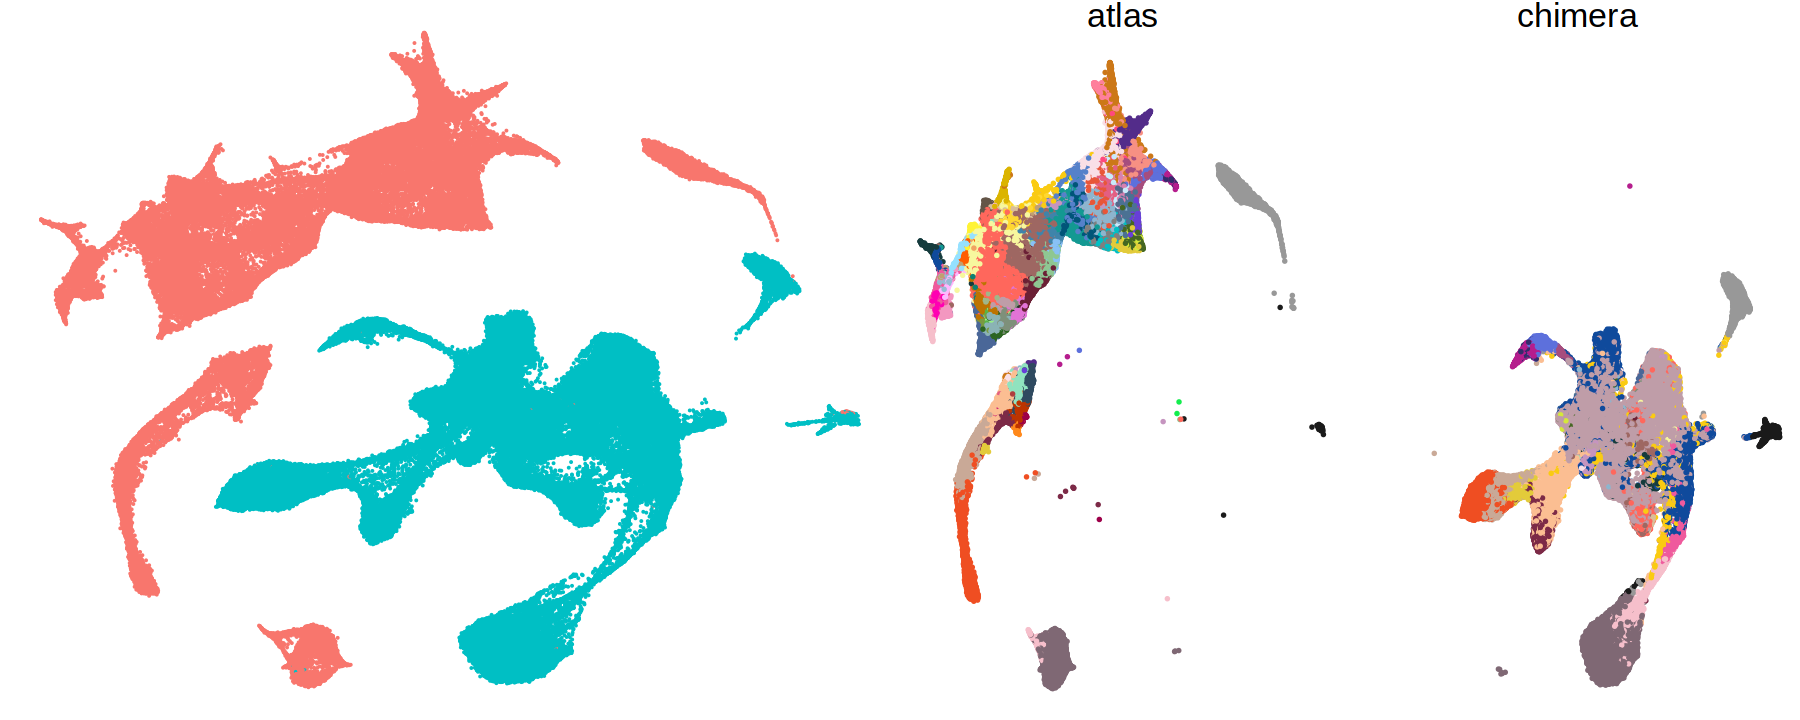

In [85]:
ggarrange(p1, p2)